# Track Statistics Analysis

**Author:** Mingshi Yang (mingshi3@illinois.edu)  
**Date:** 2026-01-16  

**Project:**  
*Characteristics of Midlatitude Cyclones under Climate Change in a Global Storm-Resolving Model*

**Description:**  
This notebook generates Figures 1–2 and associated Supplementary Information (SI)
figures, presenting general cyclone track statistics including frequency,
duration, seasonality, and density with large scale circulation information. 
Selected metrics are compared against corresponding statistics derived from the ERA5 reanalysis.


In [1]:
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt
import pandas as pd
from matplotlib import colors
from numpy import dtype
import xarray as xr
from scipy import stats
from datetime import date
import collections
import os
from scipy.stats import circmean
import pickle
import cartopy.crs as ccrs
from cartopy.util import add_cyclic_point

In [2]:
track_dir = '../data/tracks'
u200_dir = '../data/u200'

In [3]:
R = 6371 # radius of earth in km used to calculate density function

In [4]:
# helper functions

def subset_by_month(data, months):
    months_str = [str(month).zfill(2) for month in months]
    dates_str = np.int64(data[:, 0]).astype(str)
    months_data = np.array([date[4:6] for date in dates_str])
    # Find the indices where the month is in the list of months
    indices = np.isin(months_data, months_str)
    # Filter the array based on these indices
    subset_data = data[indices].copy()
    return subset_data

def filterlat(data,nlat,nlon,v_lat):
    data2 = np.ones((nlat,nlon))
    j = len(data[0])
    for i in range(len(data)):
        w = int(min(j,1/np.cos(np.deg2rad(v_lat[i]))))
        #print(w)
        arr = np.append(data[i],data[i])
        #print(arr)
        arr2 = np.ones_like(data[i])
        for k in range(j):
            arr2[(k+int(j/2))%j] *= np.nanmean(arr[k+int(j/2)-w:k+int(j/2)+w+1])
            #print(k+int(j/2)-w,k+int(j/2)+w+1)
        arr2[np.isnan(data[i])] = np.nan
        data2[i] *= arr2
    return data2

In [5]:
experiments = [ 'PIRE',
                'PIRE_CO2_1270ppmv',
                'PIRE_PLUS_4K',
                'PIRE_PLUS_4K_CO2_1270ppmv']

experiments_display = [ 'CTRL   ',
                '+CO₂   ',
                '+4K    ',
                '+4K+CO₂']

expnames = ['ERA5   '] + experiments_display

colorlist = ['gray','black','C0','C1','C3']

all_tracks files are created by concating all tracks produced by Crawford et al. (2021) to a single text file
there is a paired index file noting beginning and ending line numbers of each track

In [6]:
# x-shield data
data = []
idx = []
for exp in experiments:
    data.append(np.loadtxt(f'{track_dir}/TK2Y-{exp}/All_Tracks.txt'))
    idx.append(np.loadtxt(f'{track_dir}/TK2Y-{exp}/All_Indexes.txt'))

In [7]:
# compare with ERA5 data
TK = np.loadtxt(f'{track_dir}/TK2Y-ERA5/All_Tracks.txt')
TKIDX = np.loadtxt(f'{track_dir}/TK2Y-ERA5/All_Indexes.txt')

Figure 1 and associated SI figures

In [8]:
# timesteps in tracks are in YYYYMMDDHH format
# to produce Figures S3-S4, modify starting time and ending time in this cell
# - e.g., 2020 only: time_begin = 2020 and time_end = 2020
time_begin = 2020 # inclusive
time_end = 2021 # inclusive
# they will be multipled by 1000000 as selection range of timesteps in tracks

In [9]:
# crawford era5 track
tk2 = TK[(TK[:,0]>(time_begin*1000000))&(TK[:,0]<((time_end+1)*1000000)),:] # ERA5 in 2020-2021
tk2 = tk2[(tk2[:,1] < 65)&(tk2[:,1] >= 30)] # midlatitude cyclone criteria

# monthly frequency used in figure 1
mon = tk2[:,0] // 10000 % 100 # month identifier
histd_era5, bin_edges = np.histogram(mon,bins=np.linspace(0.5,12.5,13),density=False)

MC sample size 29884 0.999999853067374


C:\Users\yangm\AppData\Local\Temp\ipykernel_30976\733392147.py:49: RuntimeWarning: divide by zero encountered in divide
  axes[0].plot(x/mask, y/mask, color=colorlist[0], alpha=0.6, linestyle='--')


ERA5 CTRL    TtestResult(statistic=np.float64(-23.184164222092637), pvalue=np.float64(2.2278159258132295e-118), df=np.float64(59074.0))
ERA5 CTRL    LeveneResult(statistic=np.float64(52.027392959224365), pvalue=np.float64(5.53861207808542e-13))
MC sample size 29192 0.9999998396963166
mean: +CO₂    993.9803089454784 CTRL    993.7714881094136
1 CTRL    +CO₂    TtestResult(statistic=np.float64(1.9680732287088034), pvalue=np.float64(0.049064496455928724), df=np.float64(56482.0))
1 CTRL    +CO₂    LeveneResult(statistic=np.float64(4.72957438197612), pvalue=np.float64(0.02965235630232653))
MC sample size 27292 0.9999998659306808


C:\Users\yangm\AppData\Local\Temp\ipykernel_30976\733392147.py:84: RuntimeWarning: divide by zero encountered in divide
  axes[0].plot(x/mask, y/mask, linestyle='--', color=colorlist[i+1], alpha=0.6)
C:\Users\yangm\AppData\Local\Temp\ipykernel_30976\733392147.py:84: RuntimeWarning: divide by zero encountered in divide
  axes[0].plot(x/mask, y/mask, linestyle='--', color=colorlist[i+1], alpha=0.6)


mean: +4K     993.6882969646826 CTRL    993.7714881094136
2 CTRL    +4K     TtestResult(statistic=np.float64(-0.718808634647395), pvalue=np.float64(0.4722619769965887), df=np.float64(53484.0))
2 CTRL    +4K     LeveneResult(statistic=np.float64(96.96751699613998), pvalue=np.float64(7.37030516987565e-23))
MC sample size 24294 0.9999996871782396


C:\Users\yangm\AppData\Local\Temp\ipykernel_30976\733392147.py:84: RuntimeWarning: divide by zero encountered in divide
  axes[0].plot(x/mask, y/mask, linestyle='--', color=colorlist[i+1], alpha=0.6)


mean: +4K+CO₂ 994.0095132080772 CTRL    993.7714881094136
3 CTRL    +4K+CO₂ TtestResult(statistic=np.float64(2.1069814427186313), pvalue=np.float64(0.03512377919471078), df=np.float64(54099.0))
3 CTRL    +4K+CO₂ LeveneResult(statistic=np.float64(34.30894421572865), pvalue=np.float64(4.729275654067684e-09))
MC sample size 24909 0.9999997684751853


C:\Users\yangm\AppData\Local\Temp\ipykernel_30976\733392147.py:84: RuntimeWarning: divide by zero encountered in divide
  axes[0].plot(x/mask, y/mask, linestyle='--', color=colorlist[i+1], alpha=0.6)


ERA5 min dur: 1.0 | #TC: 2420
CTRL    min dur: 1.0 | #TC: 2464
+CO₂    min dur: 1.0 | #TC: 2294
1 CTRL    +CO₂    TtestResult(statistic=np.float64(-1.256863747213877), pvalue=np.float64(0.20886470036671795), df=np.float64(4756.0))
1 CTRL    +CO₂    LeveneResult(statistic=np.float64(1.0239313129393577), pvalue=np.float64(0.3116397780183752))
+4K     min dur: 1.0 | #TC: 2029
2 CTRL    +4K     TtestResult(statistic=np.float64(-1.6160980210177345), pvalue=np.float64(0.10614336040301428), df=np.float64(4491.0))
2 CTRL    +4K     LeveneResult(statistic=np.float64(3.7546577740038494), pvalue=np.float64(0.05272318709590032))
+4K+CO₂ min dur: 1.0 | #TC: 2065
3 CTRL    +4K+CO₂ TtestResult(statistic=np.float64(-2.815199697601847), pvalue=np.float64(0.004895764391480065), df=np.float64(4527.0))
3 CTRL    +4K+CO₂ LeveneResult(statistic=np.float64(7.30610972998469), pvalue=np.float64(0.006897709315803549))
FREQ [2873 2641 2766 2783 2757 2205 1778 1794 1985 2344 2492 2774]
FREQ [2705 2474 2904 2554 2

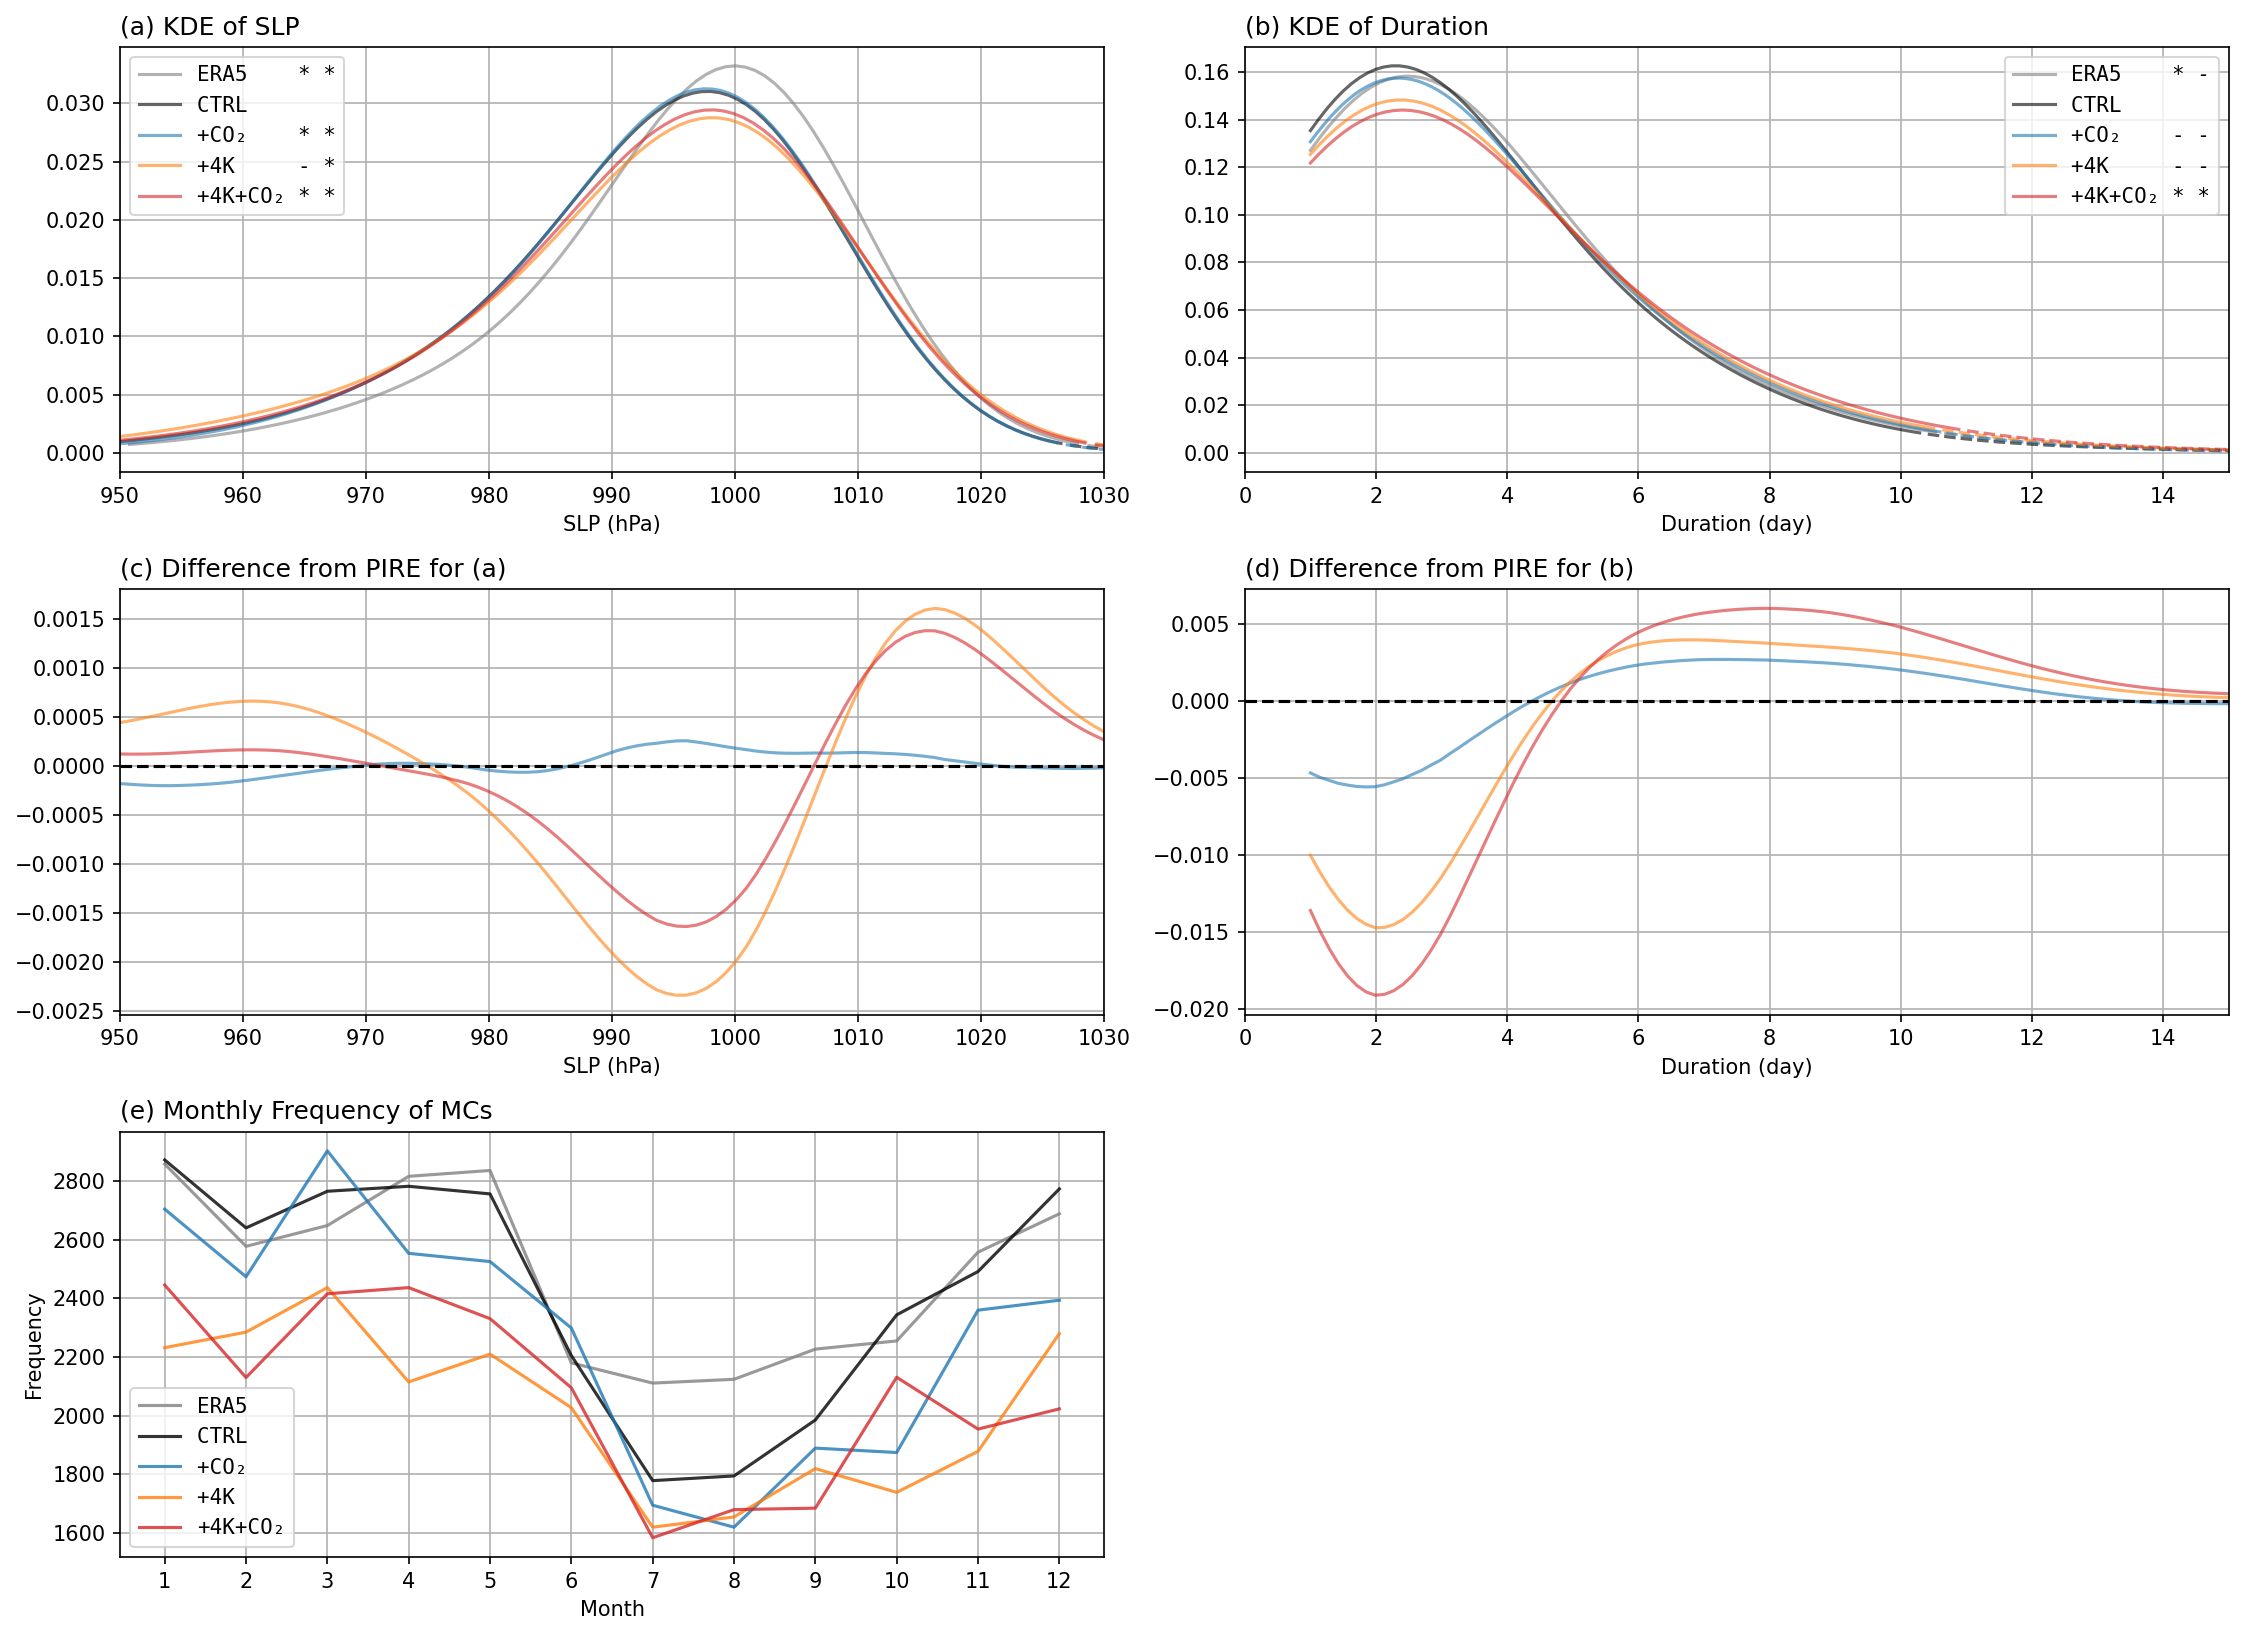

In [10]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from scipy import stats

bw = 4 # increased smoothing for kde estimate (https://seaborn.pydata.org/generated/seaborn.kdeplot.html)
threshold = 20  # samples per hPa

alpha = 0.05 # significance level of t test

fig, axesall = plt.subplots(3, 2, figsize=(15, 11),dpi=150)
axes = axesall[:2, 0]
axes_dur = axesall[:2, 1]
ax_month = axesall[2, 0]
ax_winter = axesall[2,1]
#axesall[2, 1].axis('off')  # we won't use this panel

x_grid = np.linspace(920, 1040, 1201)
x_space = x_grid[1] - x_grid[0]

# Helper: extract KDE from seaborn
def get_kde_from_seaborn(data, bw_adjust, clip=None):
    temp_fig, temp_ax = plt.subplots()
    sns.kdeplot(data, bw_adjust=bw_adjust, ax=temp_ax, clip=clip, color='gray')  # dummy color
    line = temp_ax.lines[0]
    x, y = line.get_data()
    plt.close(temp_fig)
    return x, y

# ERA5 baseline
tk2_vals = tk2[:, -1]
sigs = ['-','-']
d = data[0]
d2 = d[(d[:, 0] > (time_begin*1000000)) & (d[:, 0] < ((time_end+1)*1000000)), :]
d2 = d2[:, -1][(d2[:, 1] < 65) & (d2[:, 1] >= 30)]
if stats.ttest_ind(d2, tk2_vals)[1] < alpha:
    sigs[0] = '*'
if stats.levene(d2, tk2_vals)[1] < alpha:
    sigs[1] = '*'

count = len(tk2_vals)
x, y = get_kde_from_seaborn(tk2_vals, bw)
x_space = x[1] - x[0]
print('MC sample size',count,y.sum() * x_space)
count_grid = y * count
#print(count_grid.sum())
mask = count_grid < threshold
axes[0].plot(x[~mask], y[~mask], label=expnames[0]+' '+' '.join(sigs), color=colorlist[0], alpha=0.6)
axes[0].plot(x/mask, y/mask, color=colorlist[0], alpha=0.6, linestyle='--')

kde0_x, kde0_y = None, None

for i, d in enumerate(data):
    d2 = d[(d[:, 0] > (time_begin*1000000)) & (d[:, 0] < ((time_end+1)*1000000)), :]
    d2 = d2[:, -1][(d2[:, 1] < 65) & (d2[:, 1] >= 30)]

    sigs = ['-','-']

    if i == 0:
        d0 = d2.copy()
        kde0_x, kde0_y = get_kde_from_seaborn(d0, bw)
        print('ERA5', expnames[i+1], stats.ttest_ind(d2, tk2_vals))
        print('ERA5', expnames[i+1], stats.levene(d2, tk2_vals))
        
        sigs = ['','']
    else:
        
        print('mean:',expnames[i+1],np.nanmean(d2),expnames[1],np.nanmean(d0))
        print(i, expnames[1], expnames[i+1], stats.ttest_ind(d2, d0))
        print(i, expnames[1], expnames[i+1], stats.levene(d2, d0))
        
        if stats.ttest_ind(d2, d0)[1] < alpha:
            sigs[0] = '*'
        if stats.levene(d2, d0)[1] < alpha:
            sigs[1] = '*'

    count = len(d2)
    x, y = get_kde_from_seaborn(d2, bw)
    x_space = x[1] - x[0]
    print('MC sample size', count,y.sum() * x_space)
    count_grid = y * count
    mask = count_grid < threshold
    axes[0].plot(x[~mask], y[~mask], label=expnames[i+1]+' '+' '.join(sigs), color=colorlist[i+1], alpha=0.6)
    axes[0].plot(x/mask, y/mask, linestyle='--', color=colorlist[i+1], alpha=0.6)

    if i > 0:
        # Interpolate for clean diff curve
        common_x = np.linspace(950, 1030, 100)
        y_interp = np.interp(common_x, x, y)
        y0_interp = np.interp(common_x, kde0_x, kde0_y)
        diff = y_interp - y0_interp
        axes[1].plot(common_x, diff, label=f'{expnames[i+1]}', color=colorlist[i+1], alpha=0.6)

# Styling
axes[0].legend(loc='upper left',prop={'family': 'monospace'})
axes[0].set_xlabel('SLP (hPa)')
axes[0].set_xlim(950, 1030)
axes[0].set_title("(a) KDE of SLP", loc='left')

axes[1].axhline(0, color='black', linestyle='--')
#axes[1].legend(loc='lower left')
axes[1].set_xlabel('SLP (hPa)')
axes[1].set_xlim(950, 1030)
axes[1].set_title("(c) Difference from PIRE for (a)", loc='left')

#plt.tight_layout()
#plt.show()

#axes_dur = axes[2:]
threshold = 20  # threshold for dashed line separation
bw = 4

test = stats.mannwhitneyu
test = stats.ttest_ind

# Helper: extract and mask kde
def get_kde_from_seaborn(data, bw_adjust, clip):
    temp_fig, temp_ax = plt.subplots()
    sns.kdeplot(data, bw_adjust=bw_adjust, clip=clip, ax=temp_ax, color='gray')
    line = temp_ax.lines[0]
    x, y = line.get_data()
    plt.close(temp_fig)
    return x, y

def plot_kde_with_mask(ax, x, y, label, color, count, threshold):
    x_space = x[1] - x[0]
    count_grid = y * count
    mask = count_grid < threshold
    ax.plot(x[~mask], y[~mask], label=label, color=color, alpha=0.6)
    ax.plot(x[mask], y[mask], linestyle='--', color=color, alpha=0.6)

# --- ERA5 Duration ---
dur_ref = []
dd = TK
nera=0
for im, ia in TKIDX:
    tk = dd[int(im):int(ia)].copy()
    tk = tk[((tk[:, 0] % 100) % 6) == 0]
    tk[:, -1] = np.gradient(tk[:, -1])
    step = tk[np.nanargmin(tk[:, -1])]
    if 30 <= step[1] < 65 and (time_begin*1000000) < step[0] < ((time_end+1)*1000000):
        dur_ref.append(len(tk) * 6 / 24)
        nera+=1
dur_ref = np.array(dur_ref)
print('ERA5 min dur:', dur_ref.min(), '| #TC:', nera)

x_ref, y_ref = get_kde_from_seaborn(dur_ref, bw_adjust=bw, clip=(1, np.inf))

# --- Models ---
for i, ii in enumerate(idx):
    dur = []
    dd = data[i]
    ntc = 0
    for im, ia in ii:
        tk = dd[int(im):int(ia)].copy()
        tk[:, -1] = np.gradient(tk[:, -1])
        step = tk[np.nanargmin(tk[:, -1])]
        if 30 <= step[1] < 65 and (time_begin*1000000) < step[0] < ((time_end+1)*1000000):
            dur.append((ia - im) * 6 / 24)
            ntc += 1
    dur = np.array(dur)
    if i == 0:
        dur_0 = dur.copy()
    print(f'{expnames[i+1]} min dur:', dur.min(), '| #TC:', ntc)

    x, y = get_kde_from_seaborn(dur, bw_adjust=bw, clip=(1, np.inf))
    if i == 0:
        x_0,y_0 = x.copy(),y.copy()

    sigs = ['-','-']
    if i > 0:
        print(i, expnames[1], expnames[i+1], test(dur_0, dur))
        print(i, expnames[1], expnames[i+1], stats.levene(dur_0, dur))
        if test(dur_0, dur)[1] < alpha:
            sigs[0] = '*'
        if stats.levene(dur_0, dur)[1] < alpha:
            sigs[1] = '*'
    else:
        #sigs = ['','']
        if test(dur_0, dur_ref)[1] < alpha:
            sigs[0] = '*'
        if stats.levene(dur_0, dur_ref)[1] < alpha:
            sigs[1] = '*'
        plot_kde_with_mask(axes_dur[0], x_ref, y_ref, label=expnames[0]+' '+' '.join(sigs), color=colorlist[0], count=len(dur_ref), threshold=threshold)
        sigs = ['','']
    plot_kde_with_mask(axes_dur[0], x, y, label=expnames[i+1]+' '+' '.join(sigs), color=colorlist[i+1], count=len(dur), threshold=threshold)

    # Difference plot
    if i > 0:
        
        common_x = np.linspace(1, 15, 100)
        y_interp = np.interp(common_x, x, y)
        y_0_interp = np.interp(common_x, x_0, y_0)
        diff = y_interp - y_0_interp
        axes_dur[1].plot(common_x, diff, label=expnames[i+1], color=colorlist[i+1], alpha=0.6)

# Styling
axes_dur[0].legend(loc='upper right',prop={'family': 'monospace'})
axes_dur[0].set_xlim(0, 15)
axes_dur[0].set_xlabel('Duration (day)')
axes_dur[0].set_title("(b) KDE of Duration", loc='left')

axes_dur[1].axhline(0, color='black', linestyle='--')
axes_dur[1].set_xlim(0, 15)
axes_dur[1].set_xlabel('Duration (day)')
axes_dur[1].set_title("(d) Difference from PIRE for (b)", loc='left')
#axes_dur[1].legend(loc='lower right')

for ax in axes:
    ax.grid()
for ax in axes_dur:
    ax.grid()


ax_month.plot(np.arange(1, 13), histd_era5, color=colorlist[0], label=expnames[0], alpha=0.8)

for i, d in enumerate(data):
    d2 = d[(d[:, 0] > (time_begin*1000000)) & (d[:, 0] < ((time_end+1)*1000000)), :]
    d2 = d2[(d2[:, 1] < 65) & (d2[:, 1] >= 30)]
    mon = d2[:, 0] // 10000 % 100
    histd, bin_edges = np.histogram(mon, bins=np.linspace(0.5, 12.5, 13), density=False)
    ax_month.plot(np.arange(1, 13), histd, linestyle='solid', label=expnames[i+1], color=colorlist[i+1], alpha=0.8)

    print('FREQ', histd)

ax_month.set_xticks(np.arange(1, 13))
ax_month.set_xlabel('Month')
ax_month.set_ylabel('Frequency')
ax_month.set_title('(e) Monthly Frequency of MCs', loc='left')
ax_month.grid()
ax_month.legend(prop={'family': 'monospace'})

# duration change in winter

def compute_duration_by_season(data_array, index_array, is_model=False):
    durations_winter = []
    durations_summer = []
    for im, ia in index_array:
        tk = data_array[int(im):int(ia)].copy()
        tk = tk[((tk[:, 0] % 100) % 6) == 0]
        tk[:, -1] = np.gradient(tk[:, -1])
        step = tk[np.nanargmin(tk[:, -1])]
        if 30 <= step[1] < 65 and (time_begin*1000000) < step[0] < ((time_end+1)*1000000):
            duration = (ia - im) * 6 / 24 if is_model else len(tk) * 6 / 24
            t_s0 = step[0]
            for time_year in range(time_begin, time_end+1):
                if (t_s0 >= time_year*1000000 and t_s0 < time_year*1000000 + 30000) \
                    or (t_s0 >= time_year*1000000 + 120000 and t_s0 < (time_year+1)*1000000): # Jan, Feb, Dec of current year
                    durations_winter.append(duration)
                elif (t_s0 >= time_year*1000000 + 60000 and t_s0 < time_year*1000000 + 90000): # June - August
                    durations_summer.append(duration)
            #if step[0] < 2020030000 or (step[0] >= 2020120000 and step[0] < 2021030000) or step[0] >= 2021120000:
            #    durations_winter.append(duration)
            #elif (2020060000 <= step[0] < 2020090000) and (2021060000 <= step[0] < 2021090000):
            #    durations_summer.append(duration)
    return np.array(durations_winter), np.array(durations_summer)

# ERA5
dur_ref_winter, dur_ref_summer = compute_duration_by_season(TK.copy(), TKIDX.copy())

# this part is used to plot Figure S1
durs_winter, durs_summer = [], []
for i in range(len(data)):
    d_w, d_s = compute_duration_by_season(data[i].copy(), idx[i].copy(), is_model=True)
    durs_winter.append(d_w)
    durs_summer.append(d_s)

ax = ax_winter

ax.axis('off')

plt.tight_layout()
plt.show()


Figure S1

[ 2.  4.  6.  8. 10. 12.]
[ 1  3  5  7  9 11 13]


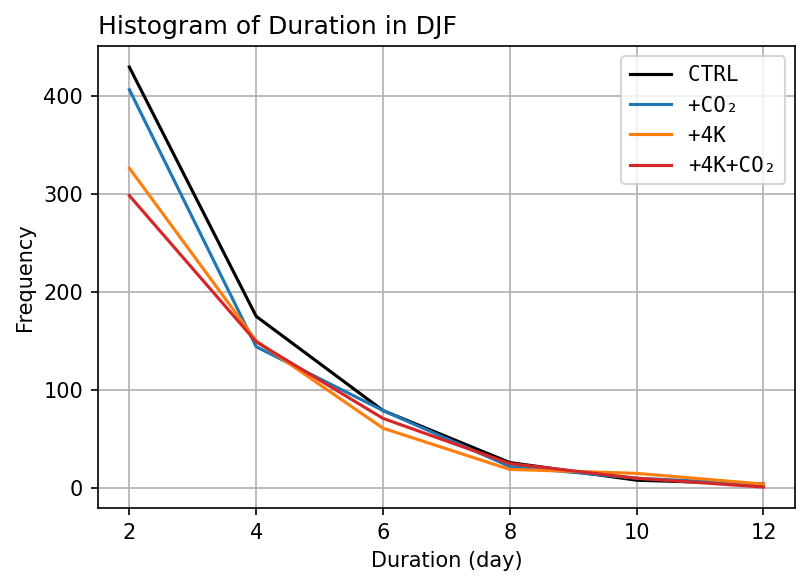

In [11]:
bins = np.arange(1, 15, 2)
bin_centers = (bins[:-1] + bins[1:]) / 2
print(bin_centers)
print(bins)

fig,ax = plt.subplots(figsize=(6,4),dpi=150)
for i, dur in enumerate(durs_winter): # this is calculated during plotting Figure 1 in cell above
    hist, _ = np.histogram(dur, bins=bins)
    if i == 0:
        h0 = hist.copy()
    ax.plot(bin_centers, hist , color=colorlist[i+1],label=expnames[i+1])

ax.set_xlabel('Duration (day)')
ax.set_ylabel('Frequency')
ax.set_title('Histogram of Duration in DJF',loc='left')
ax.legend(prop={'family': 'monospace'})
ax.grid()

Calculate and plot Figure 2

In [12]:
# use 72 / 15 bins in lon/lat axes
llon = 72
llat = 15
blat = np.linspace(0,75,llat+1)
blon = np.linspace(0,360,llon+1)
v_lat = (blat[1:]+blat[:-1])/2
print(v_lat)

# compute area of each bin for normalization later
area_weight = 2 * np.pi * R**2 * np.abs(np.sin(np.deg2rad(blat[1:])) - np.sin(np.deg2rad(blat[:-1]))) / llon
area_weight = np.zeros((len(area_weight),llon)) + area_weight[:,None]
area_weight.shape

[ 2.5  7.5 12.5 17.5 22.5 27.5 32.5 37.5 42.5 47.5 52.5 57.5 62.5 67.5
 72.5]


(15, 72)

In [13]:
# load U200 for CTRL (dataset inspection, each experiment will be reloaded when plotting)
exp = experiments[0]
folder = f'{u200_dir}/{exp}_monthlymean'
file = [os.path.join(folder,f) for f in os.listdir(folder) if '.nc' in f if 'u200' in f if ('2020' in f or '2021' in f)]
file.sort()
print(len(file))
ds = xr.open_mfdataset(file,concat_dim='month', combine='nested')

24


In [14]:
ds

<xarray.Dataset> Size: 100MB
Dimensions:              (month: 24, grid_yt_coarse: 720, bnds: 2,
                          grid_xt_coarse: 1440)
Coordinates:
  * grid_yt_coarse       (grid_yt_coarse) float32 3kB -89.88 -89.62 ... 89.88
  * grid_xt_coarse       (grid_xt_coarse) float32 6kB 0.125 0.375 ... 359.9
Dimensions without coordinates: month, bnds
Data variables:
    grid_yt_coarse_bnds  (month, grid_yt_coarse, bnds) float32 138kB dask.array<chunksize=(1, 720, 2), meta=np.ndarray>
    grid_xt_coarse_bnds  (month, grid_xt_coarse, bnds) float32 276kB dask.array<chunksize=(1, 1440, 2), meta=np.ndarray>
    u200_coarse          (month, grid_yt_coarse, grid_xt_coarse) float32 100MB dask.array<chunksize=(1, 720, 1440), meta=np.ndarray>

[ 2  3  4  5  6  7  8  9 10 11 12 13 14]
35521.0
35521.0
[0] count shape: (15, 73), valid: 1095
24
(360, 1440)
[ 2  3  4  5  6  7  8  9 10 11 12 13 14]
33666.0
33666.0
[1] count shape: (15, 73), valid: 1095
24
(360, 1440)
[ 2  3  4  5  6  7  8  9 10 11 12 13 14]
30586.0
30586.0
[2] count shape: (15, 73), valid: 1095
24
(360, 1440)
[ 2  3  4  5  6  7  8  9 10 11 12 13 14]
30633.0
30633.0
[3] count shape: (15, 73), valid: 1095
24
(360, 1440)


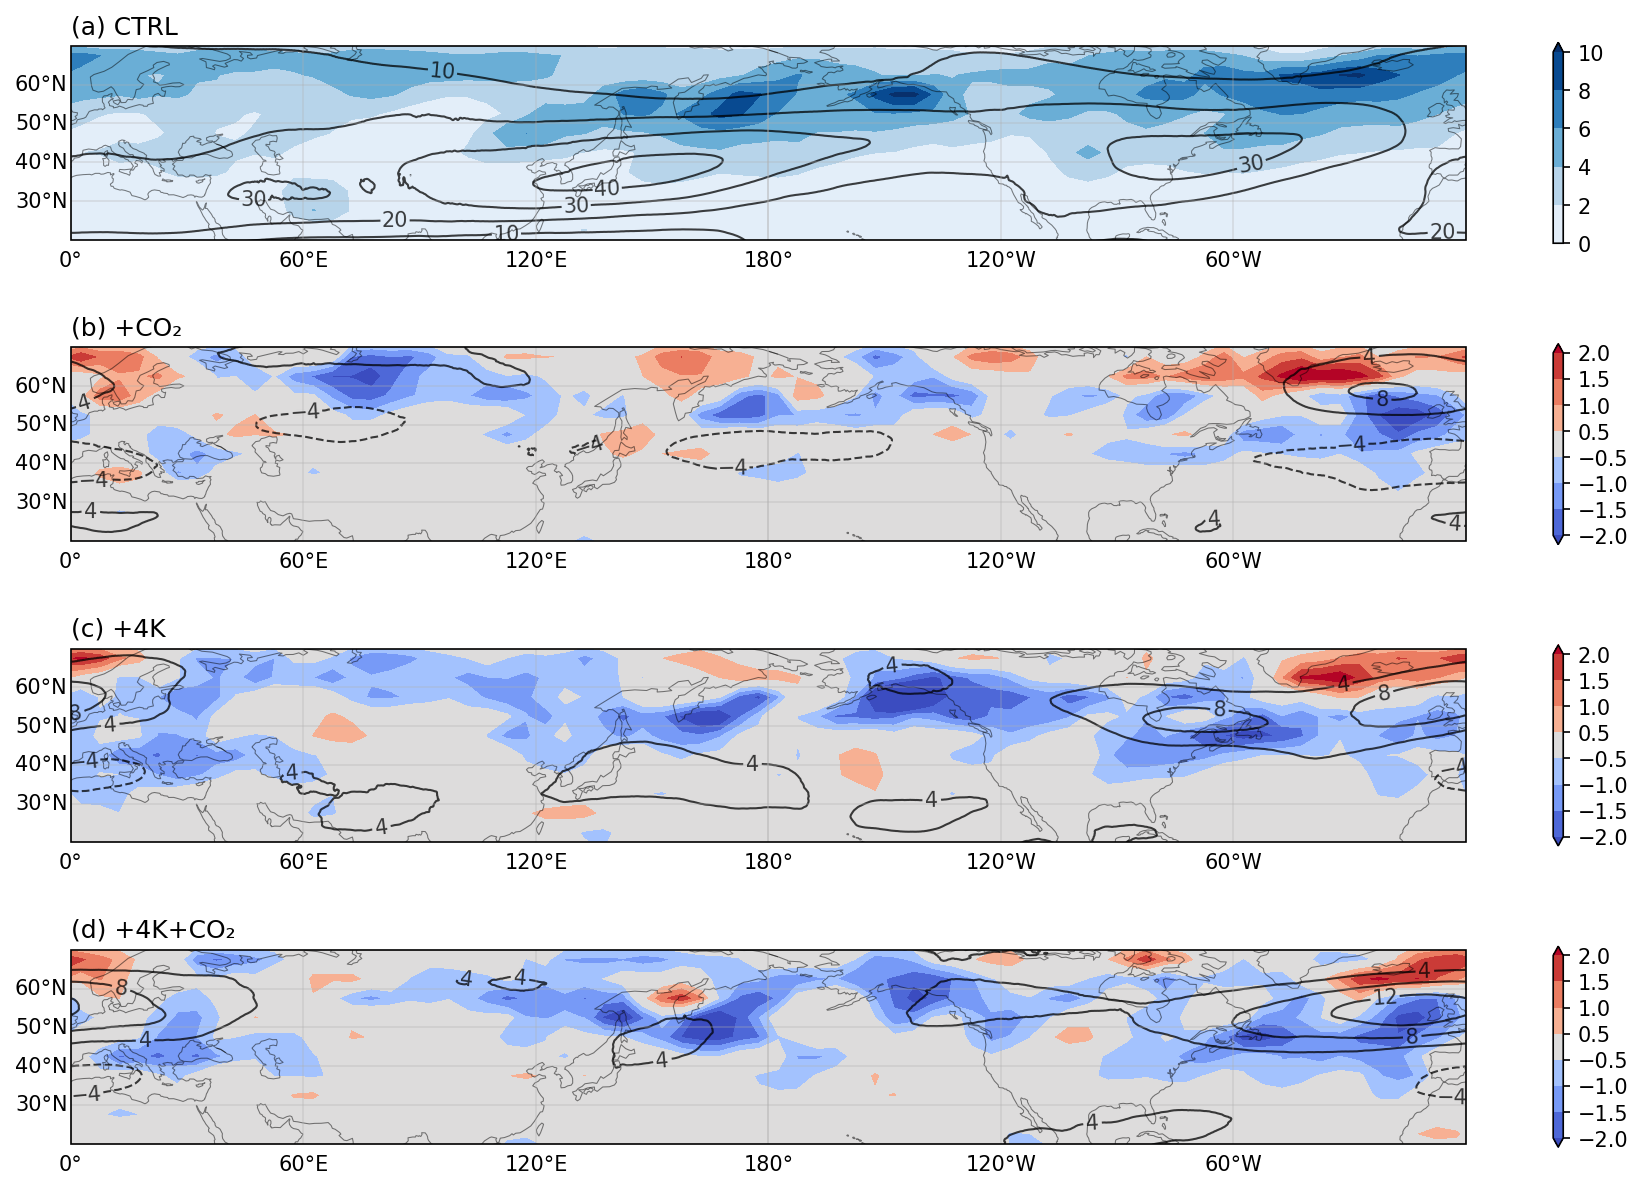

In [15]:
# Figure 2 plotting
letters = 'abcdefg'

month_idx = np.array(np.arange(24),dtype=np.int32)
jlevel = np.linspace(-20,20,11)
jlevel = [j for j in jlevel if j != 0]

dlevel = np.linspace(0,5,6)*2
ddlevel = np.array([-2,-1.5,-1,-0.5,0.5,1,1.5,2])

fig,axes = plt.subplots(4,1,figsize=(15,10),dpi=150,subplot_kw={'projection': ccrs.PlateCarree(central_longitude=180)})


for jfig, dd in enumerate(data):
    ifig = jfig

    # calc density map:
    #   get all samples in 2020-2021 (not only MCs as the map covers larger latitude range and to show storm track shift)
    #   count frequency in each bin
    #   apply some smoothing (wider rolling window size at higher latitude proportional to 1/cos(lat), total count not changed)
    #   normalize by area of each bin

    dd = dd[(dd[:,0]>(time_begin*1000000))&(dd[:,0]<((time_end+1)*1000000)),:]
    dd = dd[dd[:,1] < 70]
    lat,lon = dd[:,1], dd[:,2]
    ilat = np.digitize(lat,blat)
    print(np.unique(ilat))
    
    ilon = np.digitize(lon,blon)
    count = np.zeros((llat,llon))
    for i in range(len(lat)):
        count[ilat[i]-1,ilon[i]-1] += 1
    print(np.sum(count))
    count = filterlat(count,llat,llon,v_lat)
    print(np.sum(count))
    count /= area_weight

    count,lon2 = add_cyclic_point(count,(blon[1:]+blon[:-1])/2)

    #print(count.shape)
    axes[ifig].coastlines(linewidth=0.5,alpha=0.5)

    exp = experiments[jfig]

    if jfig == 0: # CTRL and total field
        count0 = count.copy()
        
        print(f'[{ifig}] count shape: {count0.shape}, valid: {np.isfinite(count0).sum()}')

        cf = axes[ifig].contourf(lon2,v_lat,count0*10000,transform=ccrs.PlateCarree(),cmap='Blues',
            norm=None,levels=dlevel,extend='max')

        exp = experiments[0]
        folder = f'{u200_dir}/{exp}_monthlymean'
        file = [os.path.join(folder,f) for f in os.listdir(folder) if '.nc' in f if 'u200' in f if ('2020' in f or '2021' in f)]
        file.sort()
        print(len(file))
        ds = xr.open_mfdataset(file,concat_dim='month', combine='nested')
        dmon0 = ds['u200_coarse'].sel(month=month_idx).values.mean(axis=0)[360:]
        #print(dmon0)
        print(dmon0.shape)
        #break

        cu = axes[0].contour(np.linspace(0.125,359.875,1440),np.linspace(0.125,89.875,360),dmon0,transform=ccrs.PlateCarree(),
            colors='black',levels=np.linspace(0,80,9),linewidths=1,alpha=0.75)
        
        axes[ifig].clabel(cu)

        plt.colorbar(cf,ax=axes[ifig],shrink=0.8)

    else: # sensitivity experiments and perturbed fields
        
        print(f'[{ifig}] count shape: {count.shape}, valid: {np.isfinite(count).sum()}')

        cf = axes[ifig].contourf(lon2,v_lat,(count-count0)*10000,transform=ccrs.PlateCarree(),cmap='coolwarm',
            norm=None,levels=ddlevel,extend='both')

        folder = f'{u200_dir}/{exp}_monthlymean'
        file = [os.path.join(folder,f) for f in os.listdir(folder) if '.nc' in f if 'u200' in f if ('2020' in f or '2021' in f)]
        file.sort()
        print(len(file))
        ds = xr.open_mfdataset(file,concat_dim='month', combine='nested')
        dmon = ds['u200_coarse'].sel(month=month_idx).values.mean(axis=0)[360:]
        print(dmon.shape)

        cu = axes[ifig].contour(np.linspace(0.125,359.875,1440),np.linspace(0.125,89.875,360),(dmon-dmon0),transform=ccrs.PlateCarree(),
            colors='black',levels=jlevel,linewidths=1,alpha=0.75)

        axes[ifig].clabel(cu)
        plt.colorbar(cf,ax=axes[ifig],shrink=0.8)

    axes[ifig].set_extent([-180,180,20,70],ccrs.PlateCarree())
    #plt.colorbar(cf,ax=axes[label])
    
    axes[ifig].set_title(f'({letters[ifig]}) ' + expnames[ifig+1],loc='left')#,color=colorlist[ifig+1])
    gl = axes[ifig].gridlines(alpha=0.33)
    gl.left_labels = True
    gl.bottom_labels = True

# since multiplied density by 10000 during plotting, unit of density is count per 10000 km^2
